# Basic Python
## Part 1: Logic and String Manipulation

**1.a The DNA Helix Printer**
Write a function `print_helix(n, turns)` where `n` is the width of the helix and `turns` is the number of full cycles. The helix is formed by two strands.
* The strands oscillate using a sine-wave-like pattern.
* The characters for the strands should cycle through `A, C, G, T`.
* **Constraint:** You must handle the spacing dynamically.

**Example Output (`n=4, turns=1`):**
```text
A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G

In [20]:
def spacer(n):
    print(" " * n, end='')
    
def print_helix(n, turns, sine=True):

    if n < 1 or turns < 1:
        return

    chars = ['A', 'C', 'G', 'T']

    height =  (2*n) - 1
    lines = turns * height

    for line in range(lines):
        
        if sine:
            section = (line + (line//height)) % height
        else :
            section = line % height
        
        if section < n:
            lspaces = section
        else:
            lspaces = height-1 - section

        midspaces = 2 * (n-1 - lspaces)
        char = chars[line % 4]

        if midspaces == 0:
            spacer(lspaces)
            print(char*2)
        else:
            spacer(lspaces)
            print(char, end='')
            spacer(midspaces)
            print(char)


# Test
print_helix(4, 2) #strictly sine pattern
print('\n'*2)
print_helix(4, 2, sine=False) #repeating strand

A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G
 T    T
  A  A
   CC
  G  G
 T    T
A      A
C      C



A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G
T      T
 A    A
  C  C
   GG
  T  T
 A    A
C      C


**1.b The Custom Sorter**
Write a function `sort_strings(s_list)` that takes a list of strings and sorts them based on the following priority rules:
1.  **Primary:** Length of the string (Ascending).
2.  **Secondary:** Number of distinct vowels (a, e, i, o, u) present in the string (Descending).
3.  **Tertiary:** Alphabetical order (Ascending).

**Example:**
Input: `["apple", "banana", "kiwi", "sky", "aieou", "z"]`
Output: `['z', 'sky', 'kiwi', 'aieou', 'apple', 'banana']`

In [32]:
def vowels(s):
    vowels = "aeiou"
    return -sum(1 for c in s if c.lower() in vowels)

def sort_strings(s_list):
    return sorted(s_list, key=lambda s: (len(s), vowels(s), s))

# Test
data = ["apple", "banana", "kiwi", "sky", "aieou", "z"]
print(sort_strings(data))

['z', 'sky', 'kiwi', 'aieou', 'apple', 'banana']


## Part 2: Working with Data

Consider that you are processing raw data from a sensor in a physics lab. The sensor is noisy and occasionally malfunctions.

**Task:**
1.  Read the file ```sensor_logs.csv``` **without using Pandas**.
2.  **Filter:** Ignore rows where `status` is "ERR" OR `voltage` > 10.0.
3.  **Analysis:** Calculate the **Mean** and **Standard Deviation** for each sensor.

In [ ]:
import csv
import math
from collections import defaultdict

def analyze_sensors(filename):
    sensors = defaultdict(list)

    with open(filename, 'r') as file:
        first = file.readline()
        
        file.seek(0)
        reader = csv.DictReader(file, delimiter=',')

        for row in reader:
            #all rows are fine so no need to clean or skip bad rows
            status = row['status'].strip()
            voltage = float(row['voltage'].strip())
            sensor_id = row['sensor_id'].strip()

            if status == "ERR" or voltage > 10.0:
                continue
            
            sensors[sensor_id].append(voltage)
        
    results = {}
    for sensor_id, voltages in sensors.items():
        n = len(voltages)
        if n == 0:
            continue
        mean = sum(voltages) / n
        variance = sum((v - mean) ** 2 for v in voltages) / (n-1) #n-1 since we only have experimental data so sample variance
        stddev = math.sqrt(variance)
        results[sensor_id] = {"mean": mean, "stddev": stddev}

    for sensor_id in sorted(results.keys()):
        mean = results[sensor_id]["mean"]
        stddev = results[sensor_id]["stddev"]
        print(f"Sensor ID: {sensor_id}, Mean Voltage: {mean:.2f}, Std Dev: {stddev:.2f}")

analyze_sensors("sensor_log.csv")

Sensor ID: S1, Mean Voltage: 4.03, Std Dev: 0.55
Sensor ID: S2, Mean Voltage: 4.06, Std Dev: 0.59
Sensor ID: S3, Mean Voltage: 3.93, Std Dev: 0.58
Sensor ID: S4, Mean Voltage: 3.97, Std Dev: 0.59


## SciPy

### Task 1

Find the positive root of the transcendental equation: $x^2 - 5\sin(x) - 2 = 0$

In [139]:
# TODO 1
from math import sin
from scipy.optimize import brentq

def f(x):
    return x**2 - 5*sin(x) - 2

root = brentq(f, 0.0, 3.0) #f(0)<0, f(3)>0
print(f"Root: {root:.5f}")

Root: 2.35424


### Task 2
Simulate a radioactive decay chain: $A \to B \to C$ (Stable).

* $\frac{dA}{dt} = -k_1 A$
* $\frac{dB}{dt} = k_1 A - k_2 B$
* $\frac{dC}{dt} = k_2 B$

Given $k_1 = 0.5$, $k_2 = 0.1$. Initial conditions: $A_0 = 100$, $B_0 = 0$, $C_0 = 0$.

You have to find the concentration of **B at t = 5.0**.

In [81]:
# TODO 2
from scipy.integrate import solve_ivp

def decay(t, y):
    A, B, C = y
    dAdt = -k1 * A
    dBdt = k1 * A - k2 * B
    dCdt = k2 * B
    return [dAdt, dBdt, dCdt]


k1 = 0.5
k2 = 0.1
A0, B0, C0 = 100.0, 0.0, 0.0

y0 = [A0, B0, C0]

t=5.0

sol = solve_ivp(decay, [0, t], y0, t_eval=[t])

A_t, B_t, C_t = sol.y[:,0]

print(f"Concentration of B at t={t} s: {B_t:.5f} mol/L")


Concentration of B at t=5.0 s: 65.55184 mol/L


# The N-Body Problem
In classical mechanics, the Two-Body problem (e.g., Earth-Moon) has an analytical solution. However, adding a third body makes the system unsolvable by pen and paper. To predict the motion of star clusters or galaxies, we solve the **N-Body problem** numerically.

**Objective:** Your task is to implement a vectorized N-Body simulation using Python and NumPy.

**Important: You are not allowed to use any loops for physics calculations.**

### The Physics & The Numerical Problem

The acceleration $\vec{a}_i$ acting on particle $i$ is the sum of gravitational forces from all other particles $j$.
$$\vec{a}_i = \sum_{j \neq i} G \cdot m_j \cdot \frac{\vec{r}_j - \vec{r}_i}{|\vec{r}_j - \vec{r}_i|^3}$$

**The Numerical Issue:**
As particles get close, $|\vec{r}_j - \vec{r}_i| \to 0$, causing the force to shoot to infinity (Singularity). In a discrete time-step simulation, this flings particles out of the galaxy at unphysical speeds.

**Q. Explain, how would you overcome this issue (you may introduce additional parameters if needed)?**

### A.
Introducing a parameter epsilon ε will solve this issue  
(Δr^2 + ε^2)^3/2

**Q. Does the value of your param ```affect``` your results? If they do then explain how.**

### A.
Yes  
If ε is too small : no point in having it, forces still shoot to infinity  
If ε is too large : forces become too weak at small ranges

### Setup and Initialization

Run this cell to import libraries and set up the simulation environment. **Do not modify this cell.**

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Simulation Parameters

G = 1.0           # Gravitational Constant
PARAM = 0.1       # Your parameter (if needed)
DT = 0.01         # Time step
STEPS = 200       # Number of steps
N_PARTICLES = 100 # Number of particles

def generate_initial_state(N, seed=42):
    """
    Generates N random particles.
    Returns:
        positions: (N, 2) array
        velocities: (N, 2) array
        masses: (N,) array
    """
    np.random.seed(seed)
    positions = np.random.randn(N, 2)
    velocities = np.random.randn(N, 2) * 0.5
    masses = np.random.rand(N) + 0.5 # Masses between 0.5 and 1.5
    return positions, velocities, masses

In [85]:
# TODO 1 : Calculates the net acceleration on every particle due to every other particle.
# You should return accelerations as a (N, 2) numpy array representing a_x, a_y

def calculate_accelerations(positions, masses, G=1.0, param=0.1):

    # TODO 1.1: Calculate the displacement vector matrix (N, N, 2)
    # Use broadcasting preferably it would be awarded accordidngly
    disp = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]
    
    # TODO 1.2: Calculate the distance squared matrix (N, N)
    dist_sq = np.sum(disp**2, axis=2) + param**2

    np.fill_diagonal(dist_sq, np.inf)

    dist_cubed = dist_sq * np.sqrt(dist_sq)

    # TODO 1.3: Find the acceleration (N, 2)
    numerator = disp * masses[np.newaxis, :, np.newaxis]
    denominator  = dist_cubed[:, :, np.newaxis]
    acc = G * (numerator) / (denominator)

    return np.sum(acc, axis=1)

In [87]:
# TODO 2: Updates the simulation by one timestep.

def symplectic_euler_step(positions, velocities, accelerations, dt):
    # TODO 2.1: Update velocities and then positions using the formulas above.
    velocities = velocities + accelerations * dt
    positions = positions + velocities * dt

    return positions, velocities

## Visualization

If your code is correct, this block will run the simulation and produce a plot.

**Note:** This block checks if your functions are implemented. If they return `None` or zeros, the plot will look static or empty.

Simulation of 100 particles for 200 steps took: 0.1500s


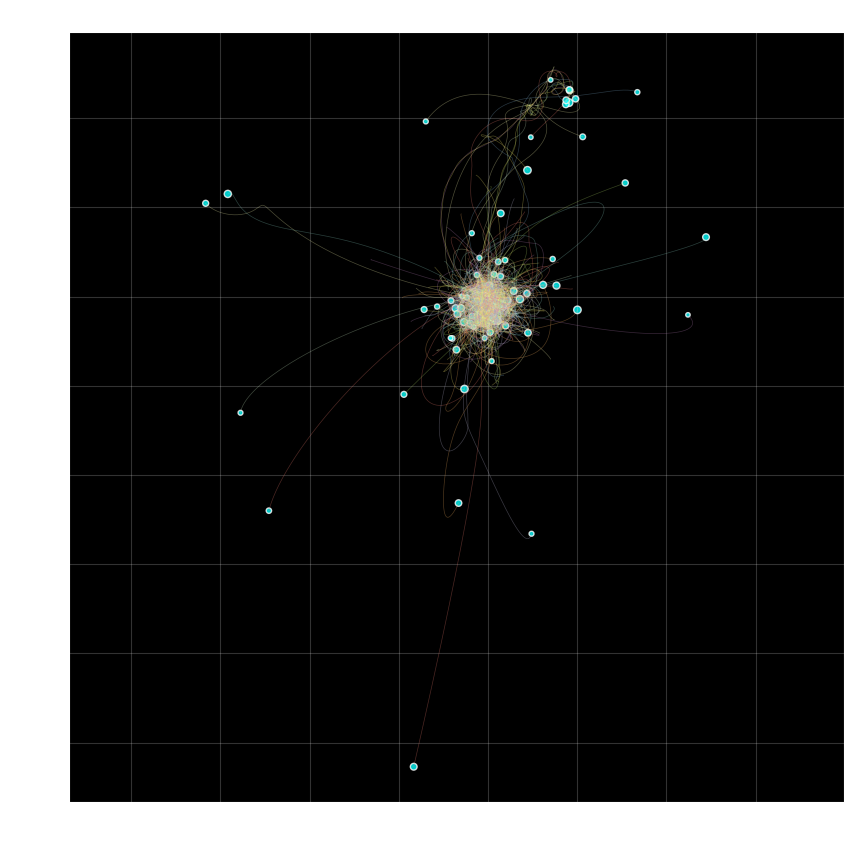

In [68]:
def run_simulation(N=100, steps=200, dt=0.01):
    positions, velocities, masses = generate_initial_state(N)
    
    trajectory_history = []
    trajectory_history.append(positions.copy())
    
    start_time = time.time()
    
    for _ in range(steps):
        # Calculate forces
        acc = calculate_accelerations(positions, masses, G, PARAM)
        
        # Integrate
        positions, velocities = symplectic_euler_step(positions, velocities, acc, dt)
        
        # Store history
        trajectory_history.append(positions.copy())
        
    end_time = time.time()
    print(f"Simulation of {N} particles for {steps} steps took: {end_time - start_time:.4f}s")
    
    return np.array(trajectory_history), masses

# Main Simualtion
history, masses = run_simulation(N=N_PARTICLES, steps=STEPS, dt=DT)

plt.figure(figsize=(10, 10))
plt.style.use('dark_background')

for i in range(N_PARTICLES):
    plt.plot(history[:, i, 0], history[:, i, 1], alpha=0.3, lw=0.5)

# Plot final positions
plt.scatter(history[-1, :, 0], history[-1, :, 1], s=masses*20, c='cyan', alpha=0.8, edgecolors='white')

plt.title(f"N-Body Simulation (N={N_PARTICLES})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()

## Conservation of Energy

A good physics simulation must conserve energy. 
* **Kinetic Energy (T):** $T = \frac{1}{2} \sum m_i v_i^2$
* **Potential Energy (U):** $U = -\frac{1}{2} \sum_i \sum_{j \neq i} \frac{G m_i m_j}{r_{ij}}$

**Note that the energy functions can also change depending on how you chose the parameter, so if you make any such modification, explain that clearly.**

**Task:** Implement the energy calculation.

In [89]:
# TODO 3: Calculate the Total Energy (Kinetic + Potential).

def calculate_total_energy(positions, velocities, masses, G=1.0, param=0.1):
    # TODO 3.1: Calculate Kinetic Energy
    speed_sq = np.sum(velocities**2, axis=1)
    T = 0.5 * np.sum(masses * speed_sq)
    
    # TODO 3.2: Calculate Potential Energy
    # Hint: You can reuse the distance matrix logic from Task 1
    disp = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]

    dist_sq = np.sum(disp**2, axis=2) + param**2

    np.fill_diagonal(dist_sq, np.inf)
    
    dist = np.sqrt(dist_sq)

    pair_mass = masses[:,None] * masses[None,:]
    
    U = -0.5 * np.sum(G * pair_mass / dist)

    return T + U

# Test for a simple 2-body static case
pos_test = np.array([[1.0, 0.0], [-1.0, 0.0]])
vel_test = np.array([[0.0, 0.0], [0.0, 0.0]])
mass_test = np.array([1.0, 1.0])

E_check = calculate_total_energy(pos_test, vel_test, mass_test, G=1.0, param=0.0)
print(f"Test Case Energy: {E_check:.4f} (Expected: -0.500)")

Test Case Energy: -0.5000 (Expected: -0.500)


## Advanced Integration with SciPy

In computational physics, we often use established libraries to verify our manual implementations. SciPy's `solve_ivp` is a powerful integrator with adaptive time-stepping.

**The Challenge:** `solve_ivp` requires the system state to be a **1D array**. You currently have 2D arrays for positions and velocities.

**TODO:**
1.  Flatten your initial `positions` and `velocities` into a single 1D array `y0`.
2.  Implement the derivative function `nbody_ode(t, y, masses, ...)` which:
    * Unpacks the 1D `y` back into `positions` and `velocities`.
    * Calculates `accelerations` using your function from Task 1.
    * Returns the derivatives (velocities and accelerations) as a flattened 1D array.
3.  Run the solver.

## 8. Task 4: Advanced Integration with SciPy
Run the simulation using `solve_ivp`.

In [93]:
from scipy.integrate import solve_ivp

# TODO 4: Implement a function nbody_ode that bridges the gap between scipy 1D requirement and your 2D logic.

def nbody_ode(t, y, masses, G):
    """
    This function takes in
        t: float, current time
        y: 1D numpy array, current state vector
        masses: (N,) array
        G: float

    This should return an array (dydt) i.e.
        1D numpy array, which time derivative of the state vector
    """
    
    N = masses.shape[0]
    
    # TODO 4.1: Unpack the 1D state vector 'y' into positions (N, 2) and velocities (N, 2)
    pos = y[:2*N].reshape(N, 2)
    vel = y[2*N:].reshape(N, 2)

    # TODO 4.2: Calculate accelerations
    # Hint: you can reuse your previous functio)
    acc = calculate_accelerations(pos, masses, G=G)
    
    # TODO 4.3: Pack the derivatives (velocities and accelerations) back into a 1D array
    dydt = np.concatenate([vel.reshape(-1), acc.reshape(-1)])
    
    return dydt

In [96]:
# TODO 5: Run the simulation using solve_ivp.

N_SCIPY = 10
pos_s, vel_s, mass_s = generate_initial_state(N_SCIPY)
t_span = (0, 2.0)
print(f"Running SciPy Integrator for N={N_SCIPY}...")

# TODO 5.1: Prepare the initial 1D state vector 'y0' from pos_s and vel_s
y0 = np.concatenate([pos_s.reshape(-1), vel_s.reshape(-1)])

# TODO 5.2: Call solve_ivp

# sol = solve_ivp(...)
sol = solve_ivp(
    nbody_ode,
    t_span,
    y0,
    args=(mass_s, G)
)

if sol:
    print(f"SciPy solved in {len(sol.t)} steps.")
    print(f"Final shape of solution: {sol.y.shape}")

Running SciPy Integrator for N=10...
SciPy solved in 63 steps.
Final shape of solution: (40, 63)


# Damped coupled oscillators

The bobs of two pendulums are connected by a spring, forming a coupled oscillator system. Real systems always have some damping, in which mechanical energy is slowly converted to heat. For this problem we model the damping as a force proportional to velocity. Assume that the spring is ideal and that the system is placed on the surface of an unknown extremely large planet. Let $\theta_1$ and $\theta_2$ denote the angles that pendulum strings make with the vertical and $t$ denote time. The equations governing the motion of the system can be written as

$$ \frac{d^2 \theta_1}{d t^2} = -c_1 \frac{d \theta_1}{d t} - k_1 \theta_1 -k_c (\theta_1 - \theta_2)$$
$$ \frac{d^2 \theta_2}{d t^2} = -c_2 \frac{d \theta_2}{d t} - k_2 \theta_2 -k_c (\theta_2 - \theta_1)$$

The file `data.csv` provides you measurements for $\theta_1$ and $\theta_2$ with time. Your task is to find $c_1, c_2, k_1, k_2, k_c$ using python (numpy and/or pandas). Note that the data might have noise and also be partially corruped due to limitations of measuring instruments.  Plot the values of $\theta_1$ and $\theta_2$ predicted using the constants calculated above against the measured values. Assume arbitrary (but consistent) unit system.

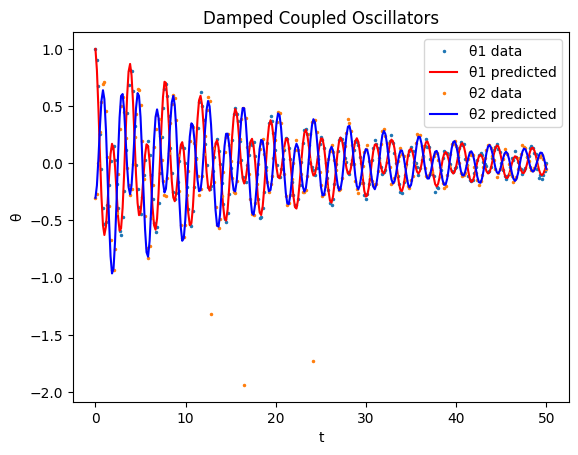

c1 = 0.169859195631843707
k1 = 1.989208313165153230
c2 = 0.000000000000000240
k2 = 2.914626321189555558
k_c = 3.999610963568942079


In [136]:
# Give the code you used for this here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

def simulate(p, t, y1, y2):
    c1,k1,c2,k2,kc = p
    def f(_, y):
        th1, th2, v1, v2 = y
        a1 = -c1*v1 - k1*th1 - kc*(th1-th2)
        a2 = -c2*v2 - k2*th2 - kc*(th2-th1)
        return [v1, v2, a1, a2]

    v10 = (y1[1]-y1[0])/(t[1]-t[0])
    v20 = (y2[1]-y2[0])/(t[1]-t[0])
    sol = solve_ivp(f, (t[0], t[-1]), [y1[0],y2[0],v10,v20], t_eval=t)
    return sol.y[0], sol.y[1]

def resid(p):
    y1,y2 = simulate(p, t3, th1_3, th2_3)
    return np.concatenate([y1-th1_3, y2-th2_3])

df = pd.read_csv("data.csv")
t = df.t.values
th1 = df.theta_1.values
th2 = df.theta_2.values

order = np.argsort(t)
t = t[order]; th1 = th1[order]; th2 = th2[order]
#only using 300 samples because my laptop was dying, also more datapoints didnt help too much
if len(t) > 300:
    use = np.linspace(0,len(t)-1,300).astype(int)
else:
    use = np.arange(len(t))

t2 = t[use]
th1_2 = th1[use]
th2_2 = th2[use]

s1 = UnivariateSpline(t2, th1_2, s=1e-3*np.var(th1_2)*300)
s2 = UnivariateSpline(t2, th2_2, s=1e-3*np.var(th2_2)*300)
a1 = s1.derivative(2)(t2)
a2 = s2.derivative(2)(t2)

mag = np.maximum(abs(a1),abs(a2))
k = mag < np.percentile(mag,95)*2

t3 = t2[k]; th1_3 = th1_2[k]; th2_3 = th2_2[k]

s1k = UnivariateSpline(t3, th1_3, s=1e-3*np.var(th1_3)*len(t3))
s2k = UnivariateSpline(t3, th2_3, s=1e-3*np.var(th2_3)*len(t3))

v1 = s1k.derivative(1)(t3)
v2 = s2k.derivative(1)(t3)
a1k = s1k.derivative(2)(t3)
a2k = s2k.derivative(2)(t3)

m = len(t3)
A = np.zeros((2*m,5))
b = np.zeros(2*m)

A[:m,0] = -v1
A[:m,1] = -th1_3
A[:m,4] = -(th1_3 - th2_3)
b[:m]   = a1k

A[m:,2] = -v2
A[m:,3] = -th2_3
A[m:,4] = -(th2_3 - th1_3)
b[m:]   = a2k

p0 = np.linalg.solve(A.T@A + 20*np.eye(5), A.T@b)

res = least_squares(resid, np.maximum(p0,1e-8), bounds=(0,np.inf), max_nfev=400)

th1p,th2p = simulate(res.x, t2, th1_2, th2_2)

plt.plot(t2,th1_2,'.',ms=3, label='θ1 data')
plt.plot(t2,th1p,'r-', label='θ1 predicted')
plt.plot(t2,th2_2,'.',ms=3, label='θ2 data')
plt.plot(t2,th2p,'b-', label='θ2 predicted')
plt.legend()
plt.xlabel("t")
plt.ylabel("θ")
plt.title("Damped Coupled Oscillators")
plt.show()

c1, k1, c2, k2, kc = res.x
print(f"c1 = {c1:.18f}")
print(f"k1 = {k1:.18f}")
print(f"c2 = {c2:.18f}")
print(f"k2 = {k2:.18f}")
print(f"k_c = {kc:.18f}")
